In [2]:
from parser import System
from optimizer import Optimizer
path_to_system_json = "./models/complete_model.json"

system = System(model_path=path_to_system_json)

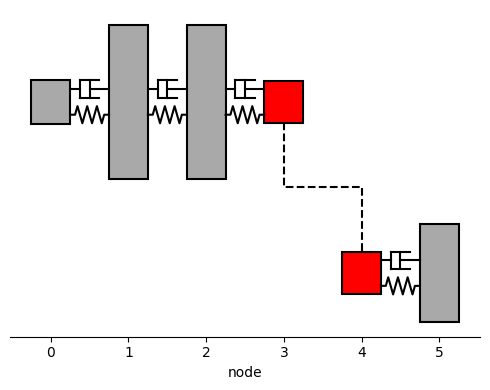

In [3]:
system.plot_assembly()

In [4]:
optimizer = Optimizer(system=system, num_generations=50, num_populations=10, verbose=True)

In [5]:
optimizer.run()

Starting optimization of 'Drivetrain System Template - Small-Scale Testbench'...
n_gen  |  n_eval  |     f_avg     |     f_min    
     1 |       10 |  1.104322E+03 |  3.808639E+02
     2 |       20 |  5.705273E+02 |  5.856704E+02
     3 |       30 |  5.778861E+02 |  5.856704E+02
     4 |       40 |  5.161603E+02 |  3.034566E+02
     5 |       50 |  6.284133E+02 |  3.031800E+02
     6 |       60 |  6.192985E+02 |  3.031800E+02
     7 |       70 |  6.306080E+02 |  3.031800E+02
     8 |       80 |  6.663040E+02 |  3.031800E+02
     9 |       90 |  6.662298E+02 |  1.333442E+03
    10 |      100 |  7.578385E+02 |  1.333442E+03
    11 |      110 |  6.812949E+02 |  3.031800E+02
    12 |      120 |  6.539415E+02 |  3.031800E+02
    13 |      130 |  7.136784E+02 |  2.858308E+02
    14 |      140 |  7.412209E+02 |  1.335385E+03
    15 |      150 |  7.308444E+02 |  1.335385E+03
    16 |      160 |  7.298226E+02 |  1.335385E+03
    17 |      170 |  7.428618E+02 |  1.335385E+03
    18 |      180 |

In [6]:
final_results = optimizer.opt_history
I_total, T_vib_max = [], []

for candidate in final_results:
    I_total.append(candidate["results"]["objectives"][1])
    T_vib_max.append(candidate["results"]["objectives"][0])

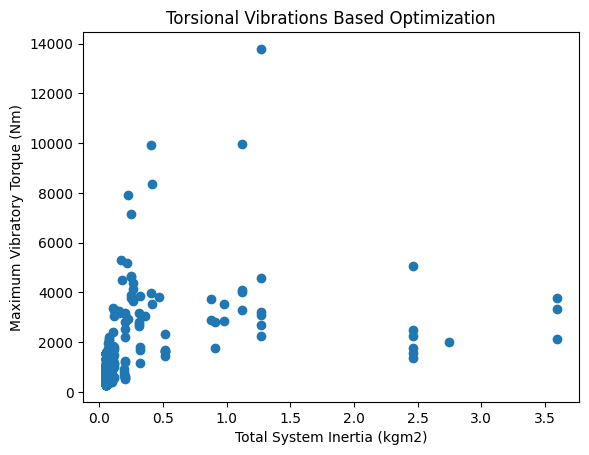

In [8]:
import matplotlib.pyplot as plt

plt.scatter(I_total, T_vib_max)
#plt.grid(True)
plt.xlabel("Total System Inertia (kgm2)")
plt.ylabel("Maximum Vibratory Torque (Nm)")
plt.title("Torsional Vibrations Based Optimization")
plt.show()

[362.1051464942759, 1426.688164359468, 1960.4969258835454, 14272.608836137473, 15642.165791061869]


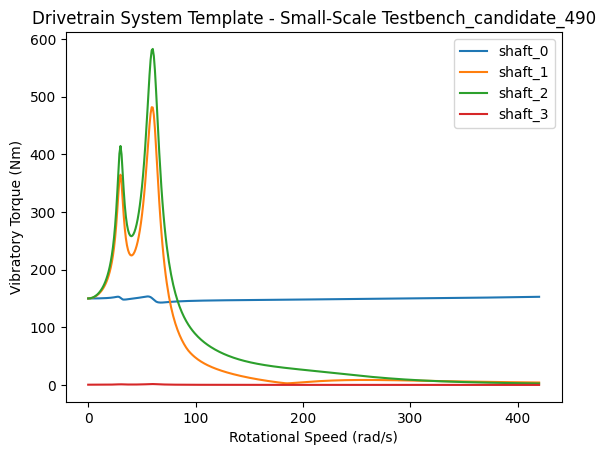

In [12]:
best_system = optimizer.final_results[0]
name = best_system["candidate"]
x = best_system["results"]["speeds (rad/s)"]
t_vibs = best_system["results"]["vibratory torque (Nm)"]
f_nat = best_system["results"]["natural freqs (rad/s)"]
print(f_nat)

for key, value in t_vibs.items():
    plt.plot(x, value, label=key)

plt.xlabel("Rotational Speed (rad/s)")
plt.ylabel("Vibratory Torque (Nm)")
plt.title(f"{name}")

plt.legend()
plt.show()


In [ ]:
# Shaft after motor: 75mm length, 16mm dia
# shaft encoder coupling: 307.5mm length, 21.44mm dia

# shaft at node 11, 16, 21: 188.86mm length, 13.09mm dia
# shaft at node 14: 320.63mm length, 14.68mm dia
